## Use pytorch to compute gradient discent

In [3]:
import torch
print(torch.__version__)

2.10.0+cu128


Use Autograd feature

In [20]:
x = torch.tensor(float(2.0), requires_grad=True)

def _sin(x):
    return torch.sin(x)

def _cos(x):
    return torch.cos(x)


In [21]:
_sin(x).backward()
print(x.grad.item())

-0.416146844625473


In [22]:
_cos(x).backward()
print(x.grad.item())

-1.325444221496582


In [27]:
print(x.grad.zero_())


tensor(0.)


In [28]:
_cos(x).backward()
print(x.grad.item())

-0.9092974066734314


In [34]:
def _sincossum(x,y):
    return _sin(x) + _cos(y)

_sincossum(x,x).backward()
print(x.grad.item())

-2.234741687774658


In [37]:
grad1 = torch.autograd.grad(_sincossum(x, x), x, create_graph=True)[0]
print(grad1.item())
grad2 = torch.autograd.grad(grad1, x)[0]
print(grad2.item())

-1.325444221496582
-0.4931505620479584


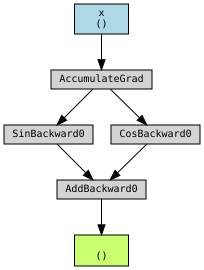

In [40]:
from torchviz import make_dot
make_dot(_sincossum(x,x), params={'x': x})

`_sincossum(x, x)$` computes `sin(x) + cos(x)`, so the graph should show:

- **AddBackward** at the top — the final `+` operation.

- Two branches below it:
    - **SinBackward** — from `sin(x)`
    - **CosBackward** — from `cos(x)`

- Both branches converge to the same leaf node x

It's a tree that mirrors the expression exactly: 
an addition of two unary operations on the same input. During `.backward()`, gradients flow from the top down both branches and accumulate at `x`, giving you `cos(x) + (-sin(x))` — which is why your grad was `-1.3254` (i.e., `cos(2) - sin(2)`).

---

## High Dimenational Gaussian Distribution

A multivariate Gaussian (multivariate normal distribution) is the generalization of the 1D normal distribution to multiple dimensions.

For a random vector x of dimension k:

$$\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$$

μ — mean vector (k × 1), the center of the distribution
Σ — covariance matrix (k × k), controls the spread and correlation between dimensions
The PDF is:

$$p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^k |\boldsymbol{\Sigma}|}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

Key intuitions:

Diagonal Σ → dimensions are independent, the shape is an axis-aligned ellipsoid
Off-diagonal entries → dimensions are correlated, the ellipsoid is rotated
The 1D case is just k = 1, where Σ becomes the scalar variance σ²

When can we say that x and y are ~ Gaussian?

Two variables x and y are jointly Gaussian if every linear combination ax + by follows a 1D Gaussian distribution.

Important distinction:

x ~ Gaussian and y ~ Gaussian individually does NOT mean they are jointly Gaussian. Two marginally normal variables can have a non-Gaussian joint distribution.
They are jointly Gaussian when the joint density has the multivariate Gaussian form with some mean vector μ and covariance matrix Σ.

Common sufficient conditions:
- They are independent and each is Gaussian → jointly Gaussian
- They are derived from linear transformations of jointly Gaussian variables
- The joint PDF is the bivariate normal formula

How to estimate μ

In practice, you estimate μ from data as the sample mean:

$$\hat{\boldsymbol{\mu}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i$$

For a 2D case with variables x and y:

$$\hat{\boldsymbol{\mu}} = \begin{bmatrix} \bar{x} \ \bar{y} \end{bmatrix} = \begin{bmatrix} \frac{1}{N}\sum x_i \ \frac{1}{N}\sum y_i \end{bmatrix}$$

It's just the mean of each dimension stacked into a vector.

How to estimate covariance matrix?

For a k-dimensional random vector with N samples:

$$\hat{\boldsymbol{\Sigma}} = \frac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^T$$

For the 2D case (x, y), this gives a 2×2 matrix:

$$\Sigma = \begin{bmatrix} \text{Var}(x) & \text{Cov}(x,y) \ \text{Cov}(y,x) & \text{Var}(y) \end{bmatrix}$$

Where:

$Var(x)$ = average of $(x - μ_x)²$
$Cov(x,y)$ = average of $(x - μ_x)(y - μ_y)$
The matrix is always symmetric since $Cov(x,y) = Cov(y,x)$
Note: use $1/(N-1)$ instead of $1/N$ for the unbiased estimator (Bessel's correction).

Density (probability density function / PDF) is the function that tells you how likely you are to find a data point at a given location. Higher density = more probability mass in that region.

For a multivariate Gaussian, the density at a point x is:

$$p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} \exp\left(-\frac{1}{2}(\mathbf{x}-\mu)^T \Sigma^{-1}(\mathbf{x}-\mu)\right)$$

Symmetric density means the contours of equal probability (level sets) form ellipsoids centered at μ. Specifically:

Points equidistant from μ (in the Mahalanobis sense) have the same density
If you move +Δ or −Δ from the mean in any direction, you get the same value of p(x)
In 2D, the contours are ellipses; in 1D, it's the familiar symmetric bell curve
This symmetry comes from the (x − μ)ᵀΣ⁻¹(x − μ) term — it's a squared distance, so the sign doesn't matter.

Calculation
Given N data points, compute element by element:

1. Means:
$$\mu_1 = \frac{1}{N}\sum_{i=1}^{N} x_1^{(i)}, \quad \mu_2 = \frac{1}{N}\sum_{i=1}^{N} x_2^{(i)}$$

2. Variance (diagonal entries):
$$\text{Var}(x_1) = \frac{1}{N}\sum_{i=1}^{N}(x_1^{(i)} - \mu_1)^2$$
$$\text{Var}(x_2) = \frac{1}{N}\sum_{i=1}^{N}(x_2^{(i)} - \mu_2)^2$$

3. Covariance (off-diagonal entries):
$$\text{Cov}(x_1, x_2) = \frac{1}{N}\sum_{i=1}^{N}(x_1^{(i)} - \mu_1)(x_2^{(i)} - \mu_2)$$

Note: Cov(x₁,x₂) = Cov(x₂,x₁), so Σ is symmetric.

Concrete example
Say you have 3 data points: (1,2), (3,4), (5,6).

Means: μ₁ = 3, μ₂ = 4

Var(x₁): ((1-3)² + (3-3)² + (5-3)²) / 3 = (4+0+4)/3 = 8/3$

Var(x₂): ((2-4)² + (4-4)² + (6-4)²) / 3 = (4+0+4)/3 = 8/3

Cov(x₁,x₂): ((1-3)(2-4) + (3-3)(4-4) + (5-3)(6-4)) / 3 = (4+0+4)/3 = 8/3


Σ = | 8/3  8/3 |
    | 8/3  8/3 |
In compact matrix form, this is the outer product of centered data:

$$\Sigma = \frac{1}{N}(X - \mu)^T(X - \mu)$$

where X is the N×2 data matrix and μ is the mean vector broadcast across rows.

## Concetration of measure

Concentration of measure is the phenomenon that in high-dimensional spaces, a random variable that depends on many independent variables (but isn't too sensitive to any single one) will be tightly concentrated around its expected value.

Core idea
In low dimensions, probability mass spreads out. In high dimensions, it concentrates. A function of many independent random variables behaves almost like a constant.

Classic example: Gaussian in high dimensions
For a d-dimensional Gaussian X ~ N(0, I_d), the squared norm ||X||² is the sum of d independent χ² variables. By the law of large numbers:

$$|X|^2 \approx d$$

More precisely, ||X|| concentrates tightly around √d. The "shell" at radius √d contains nearly all the probability mass. Almost no mass is near the origin, and almost none is far from √d.

Why it matters for ML
Curse of dimensionality: In high-d, data points become nearly equidistant from each other, which is why distance-based methods (e.g., k-NN) struggle.
Random projections: The Johnson-Lindenstrauss lemma (a concentration result) guarantees that random projections approximately preserve distances — the foundation of dimensionality reduction.
Generalization bounds: PAC-learning bounds and Rademacher complexity arguments rely on concentration inequalities to bound how much empirical risk deviates from true risk.
Key inequalities (the formal tools)
Inequality	Setting
Markov / Chebyshev	Basic, loose bounds
Hoeffding	Sum of bounded independent r.v.s
McDiarmid	Function with bounded differences
Gaussian concentration	Lipschitz functions of Gaussians
The common form: for a Lipschitz function f of n independent variables,

$$P(|f(X) - \mathbb{E}[f(X)]| \geq t) \leq 2\exp\left(-\frac{t^2}{2L^2}\right)$$

The probability of deviating by t from the mean decays exponentially in t², so large deviations are vanishingly rare in high dimensions.

The expectation (or expected value) of a random variable is its probability-weighted average — the value you'd get "on average" over infinitely many draws.

Discrete case
$$\mathbb{E}[X] = \sum_{x} x \cdot P(X = x)$$

Example: a fair die → E[X] = (1+2+3+4+5+6)/6 = 3.5

Continuous case
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f(x) , dx$$

where f(x) is the probability density function.

Key properties
Linearity: E[aX + bY] = aE[X] + bE[Y] — always holds, even if X,Y are dependent
Function of r.v.: E[g(X)] = ∫ g(x) f(x) dx (LOTUS — Law of the Unconscious Statistician)
If independent: E[XY] = E[X]·E[Y]
Connection to covariance
From your earlier question — covariance is defined in terms of expectations:

$$\text{Cov}(X,Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])] = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

And variance is just:

$$\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

So expectation is the building block underlying variance, covariance, and the entire multivariate Gaussian parameterization.

This is the expected squared distance of a random vector U from its mean μ.

Derivation
$$\mathbb{E}[|U - \mu|^2]$$

Expand the squared norm:

$$= \mathbb{E}[(U - \mu)^T(U - \mu)]$$

$$= \mathbb{E}\left[\sum_{i=1}^{d}(U_i - \mu_i)^2\right]$$

By linearity of expectation:

$$= \sum_{i=1}^{d}\mathbb{E}[(U_i - \mu_i)^2]$$

Each term is the definition of variance:

$$= \sum_{i=1}^{d}\text{Var}(U_i)$$

$$= \text{tr}(\Sigma)$$

Result
$$\boxed{\mathbb{E}[|U - \mu|^2] = \text{tr}(\Sigma)}$$

The expected squared distance from the mean equals the trace of the covariance matrix — the sum of the variances along each dimension.

Intuition
Each dimension contributes its own variance to the total expected squared distance.
For U ~ N(μ, σ²I_d) (isotropic Gaussian): tr(Σ) = dσ², so E[||U - μ||²] = dσ². This grows linearly with dimension, which ties back to concentration of measure — the mass sits on a shell at radius √(dσ²).

## Setup
$$U = \begin{bmatrix} U_1 \ V_2 \end{bmatrix}, \quad \mu = \begin{bmatrix} \mathbb{E}[U_1] \ \mathbb{E}[V_2] \end{bmatrix}$$

$$U - \mu = \begin{bmatrix} U_1 - \mathbb{E}[U_1] \ V_2 - \mathbb{E}[V_2] \end{bmatrix}$$

Squared norm
$$|U - \mu|^2 = (U_1 - \mathbb{E}[U_1])^2 + (V_2 - \mathbb{E}[V_2])^2$$

Take expectation
$$\mathbb{E}[|U - \mu|^2] = \mathbb{E}[(U_1 - \mathbb{E}[U_1])^2] + \mathbb{E}[(V_2 - \mathbb{E}[V_2])^2]$$

$$= \text{Var}(U_1) + \text{Var}(V_2)$$

$$= \sigma_{U_1}^2 + \sigma_{V_2}^2$$

$$= \text{tr}(\Sigma)$$

Which matches the general result — just the sum of the diagonal entries of:

$$\Sigma = \begin{bmatrix} \sigma_{U_1}^2 & \text{Cov}(U_1, V_2) \ \text{Cov}(V_2, U_1) & \sigma_{V_2}^2 \end{bmatrix}$$

The off-diagonal covariance terms don't appear because the cross terms vanish when you expand a squared norm — each dimension contributes independently through its variance.

Markov's inequality — the simplest concentration bound.

Statement
For a non-negative random variable X and any t > 0:

$$P(X \geq t) \leq \frac{\mathbb{E}[X]}{t}$$

Intuition
If the average is small, the random variable can't be large too often. If E[X] = 1, then X ≥ 100 can happen at most 1/100 of the time — otherwise the average would be pulled higher.

Proof (one line)
$$\mathbb{E}[X] = \int_0^\infty x , f(x) , dx \geq \int_t^\infty x , f(x) , dx \geq t \int_t^\infty f(x) , dx = t \cdot P(X \geq t)$$

Rearrange → done.

Why it matters
It's the foundation of the stronger inequalities:

Apply Markov to...	You get...
X directly	Markov
(X - μ)²	Chebyshev
e^{sX}	Chernoff / Hoeffding
Chebyshev is just Markov applied to (X - μ)²:

$$P(|X - \mu| \geq t) = P((X-\mu)^2 \geq t^2) \leq \frac{\text{Var}(X)}{t^2}$$

Chernoff is Markov applied to e^{sX}, which gives the exponential tail decay you saw in concentration of measure.

Limitation
Markov is loose — it only uses the mean. Each step up the chain (Chebyshev → Chernoff) uses more information about the distribution and gives a tighter bound.